# Deliverable 1 — Data pipeline

Indexes EuroSAT (27,000 tiles, 10 classes), builds a **spatial-block** train/val/test split (whole contiguous tile blocks assigned to one split, never individual tiles — see explanation below), decodes the UC Merced parquet into an ImageFolder tree, and visualises 5 samples/class plus the class distribution.

Run top-to-bottom. Requires the project `.venv` as the kernel (`torch`, `torchvision`, `pandas`, `matplotlib`, `pillow`, `datasets`, `huggingface_hub` installed).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `from src...` resolves when run from ml/notebooks/

import matplotlib.pyplot as plt
from PIL import Image

from src import config
from src.datasets import (
    assign_spatial_blocks,
    build_ucmerced_imagefolder,
    index_eurosat,
    random_image_split,
    spatial_block_split,
)

## 1. Index EuroSAT and assign spatial blocks

EuroSAT's public RGB release ships only class-labelled tiles, no per-tile lat/lon. Its original extraction walked each Sentinel-2 scene raster-by-raster, so tiles with **adjacent file indices are also adjacent on the ground** (and visually near-duplicate — same field, same cloud shadow, same crop-row pattern). We exploit that ordering: contiguous runs of 25 same-class tiles become one synthetic "spatial block", and **whole blocks** — never individual tiles — get assigned to train/val/test. This is what makes the split honest; see `src/spatial_leakage.py` for the quantified cost of skipping this step.

In [2]:
df = index_eurosat()
df = assign_spatial_blocks(df, block_size=25)
df = spatial_block_split(df, train=0.7, val=0.15, test=0.15)
print(f"{len(df)} tiles, {df['block_id'].nunique()} spatial blocks")
df["split"].value_counts()

27000 tiles, 1080 spatial blocks


split
train    18900
val       4050
test      4050
Name: count, dtype: int64

In [3]:
df.to_csv(config.DATA_DIR / "eurosat_index.csv", index=False)

# Also persist the naive random per-image split, used ONLY by the spatial-leakage
# experiment as the 'leaky' comparison point -- never for headline metrics.
df_random = random_image_split(index_eurosat())
df_random.to_csv(config.DATA_DIR / "eurosat_index_random.csv", index=False)
df.head()

,path,class_name,class_idx,file_order,block_id,split
0,C:\Users\Aryan\Desktop\NTCC\ml\data\eurosat\27...,AnnualCrop,0,0,AnnualCrop_0,val
1,C:\Users\Aryan\Desktop\NTCC\ml\data\eurosat\27...,AnnualCrop,0,1,AnnualCrop_0,val
2,C:\Users\Aryan\Desktop\NTCC\ml\data\eurosat\27...,AnnualCrop,0,2,AnnualCrop_0,val
3,C:\Users\Aryan\Desktop\NTCC\ml\data\eurosat\27...,AnnualCrop,0,3,AnnualCrop_0,val
4,C:\Users\Aryan\Desktop\NTCC\ml\data\eurosat\27...,AnnualCrop,0,4,AnnualCrop_0,val


## 2. Visualise 5 samples per class

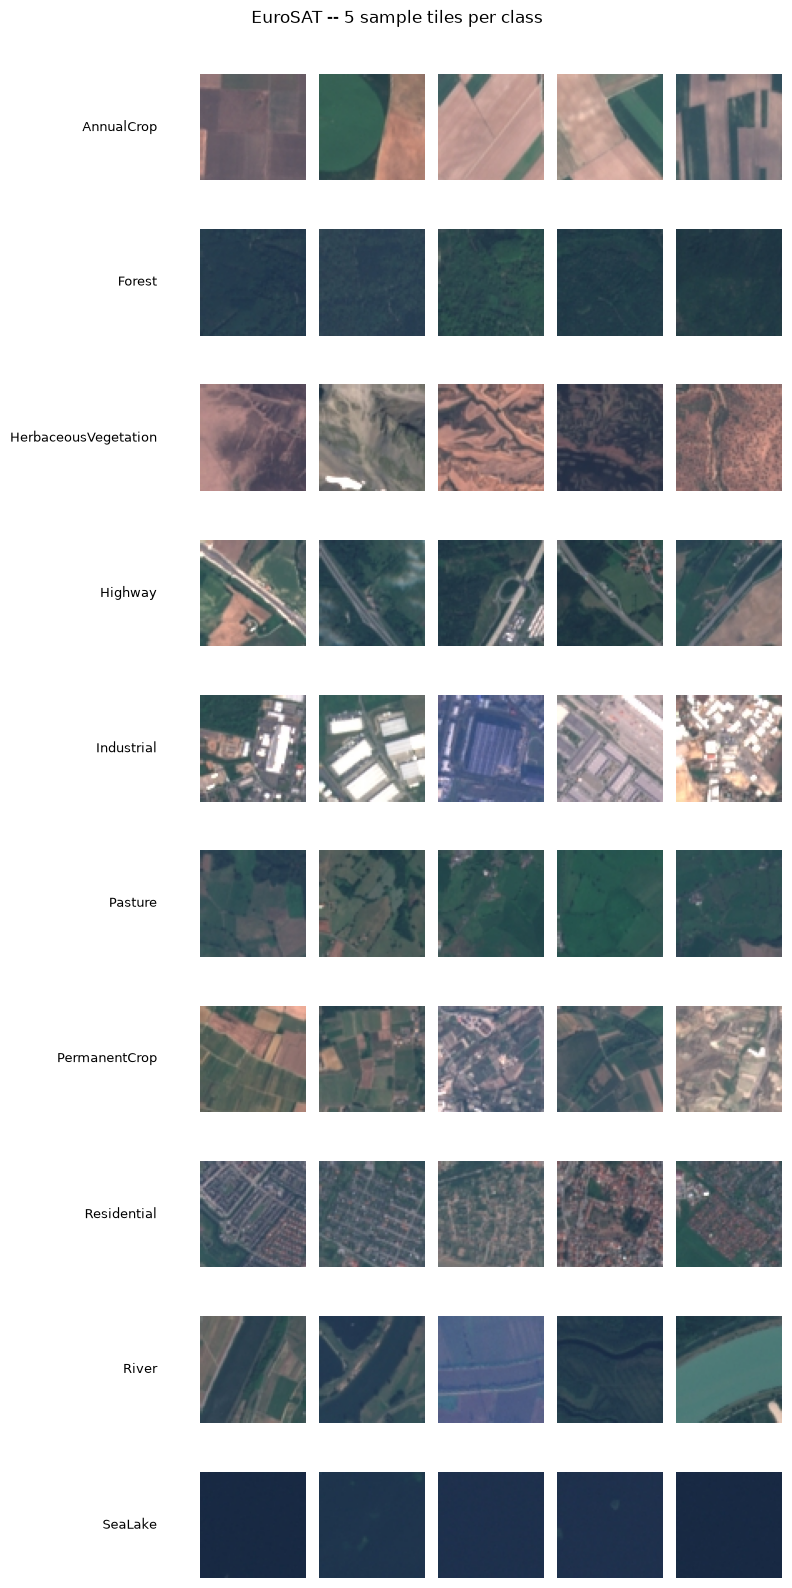

In [4]:
classes = config.EUROSAT_CLASSES
n_per_class = 5
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 1.6, len(classes) * 1.6))
for r, class_name in enumerate(classes):
    sub = df[df["class_name"] == class_name].head(n_per_class)
    for c in range(n_per_class):
        ax = axes[r, c]
        ax.imshow(Image.open(sub.iloc[c]["path"]))
        ax.axis("off")
    axes[r, 0].text(-0.4, 0.5, class_name, fontsize=9, ha="right", va="center", transform=axes[r, 0].transAxes)
fig.suptitle("EuroSAT -- 5 sample tiles per class", y=1.0)
fig.tight_layout()
plt.show()

## 3. Class distribution

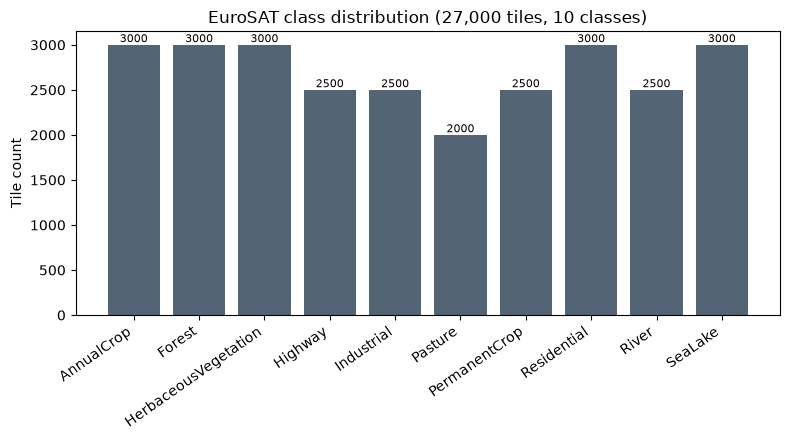

In [5]:
counts = df["class_name"].value_counts().reindex(classes)
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index, counts.values, color="#536475")
ax.set_ylabel("Tile count")
ax.set_title("EuroSAT class distribution (27,000 tiles, 10 classes)")
ax.bar_label(bars, fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.tight_layout()
plt.show()

## 4. Spatial-block split per class

Confirms every class keeps roughly the same 70/15/15 ratio even though whole blocks (not individual tiles) were assigned.

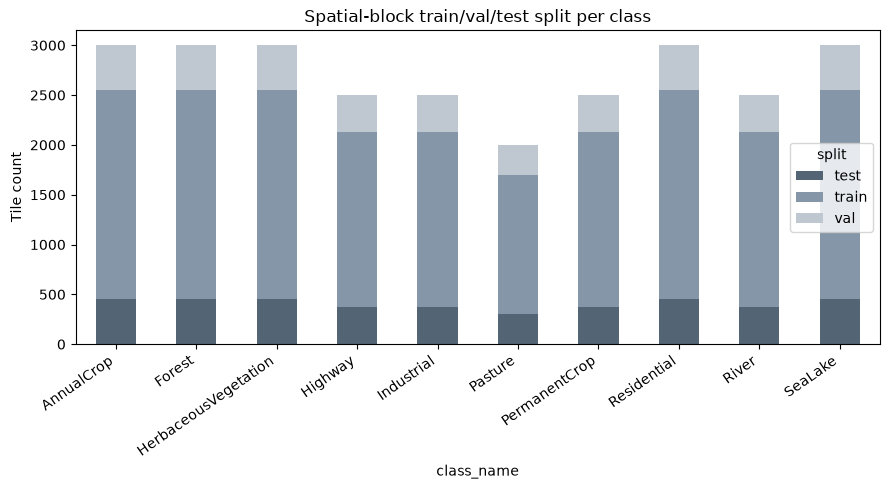

split,test,train,val
class_name,,,
AnnualCrop,450,2100,450
Forest,450,2100,450
HerbaceousVegetation,450,2100,450
Highway,375,1750,375
Industrial,375,1750,375
Pasture,300,1400,300
PermanentCrop,375,1750,375
Residential,450,2100,450
River,375,1750,375


In [6]:
pivot = df.groupby(["class_name", "split"]).size().unstack(fill_value=0).reindex(classes)
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#536475", "#8496a8", "#bfc8d1"])
ax.set_ylabel("Tile count")
ax.set_title("Spatial-block train/val/test split per class")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.tight_layout()
plt.show()
pivot

## 5. UC Merced holdout -- decode parquet to ImageFolder

UC Merced (21 classes, 2,100 images) is downloaded from the HF Hub (`blanchon/UC_Merced`) as a single parquet file and decoded here into a plain `class_name/####.jpg` directory tree so it can be loaded like any other `ImageFolder` dataset. It is used later as a **zero-shot** holdout (no fine-tuning on it) via a documented 21→10 class mapping in `src/config.py` (`UCMERCED_TO_EUROSAT`).

In [7]:
ucm_dir = build_ucmerced_imagefolder()
n_ucm = sum(1 for _ in ucm_dir.rglob("*.jpg"))
print(f"{n_ucm} UC Merced images decoded to {ucm_dir}")

2100 UC Merced images decoded to C:\Users\Aryan\Desktop\NTCC\ml\data\ucmerced


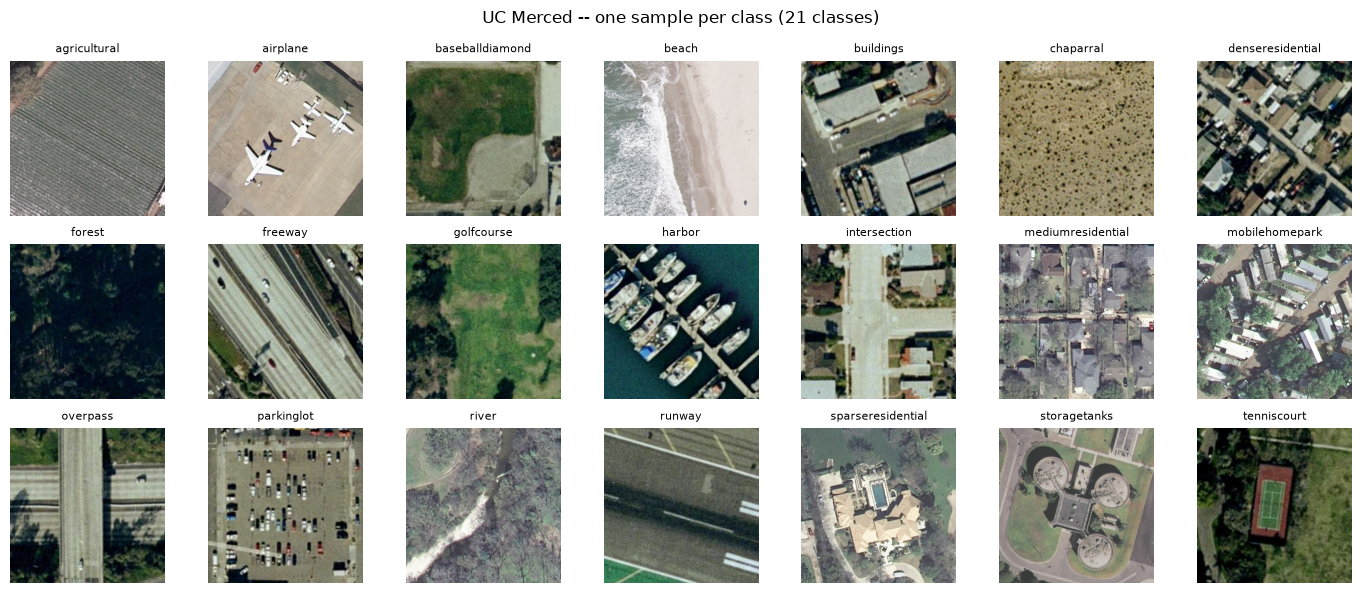

In [8]:
ucm_classes = sorted(p.name for p in ucm_dir.iterdir() if p.is_dir())
fig, axes = plt.subplots(3, 7, figsize=(14, 6))
for ax, cname in zip(axes.flat, ucm_classes):
    sample = next((ucm_dir / cname).glob("*.jpg"))
    ax.imshow(Image.open(sample))
    ax.set_title(cname, fontsize=8)
    ax.axis("off")
fig.suptitle("UC Merced -- one sample per class (21 classes)")
fig.tight_layout()
plt.show()